# Fase 6 — Modelo Predictivo LSTM

**Objetivo**: entrenar una red LSTM que prediga la **direccion del spread** a 5 dias usando ventanas de 60 dias × 15 features.

**Arquitectura**:
```
Input (batch, 60, 15)
  ↓
LSTM(hidden=32, layers=1, dropout=0.2)
  ↓
Last hidden state
  ↓
Dense(16, ReLU)
  ↓
Dropout(0.3)
  ↓
Dense(2, softmax)
  → P(spread baja a 5d) | P(spread sube a 5d)
```

**Split temporal (causal, sin shuffle)**:
- Train: 2010-2018 (~70%)
- Val: 2019-2021 (~15%)
- Test: 2022-presente (~15%)

**Anti-leakage critico**:
- Standardizer (z-score) ajustado **solo en train**, aplicado a val/test.
- Sin shuffle entre splits temporales.
- Features ya son causales por construccion (Fase 4).

**Metricas**: Accuracy, F1, AUC-ROC, Brier score.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

torch.manual_seed(42); np.random.seed(42)

DATA_DIR = Path('data')
MODELS_DIR = Path('models'); MODELS_DIR.mkdir(exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE, '| torch:', torch.__version__)

df = pd.read_parquet(DATA_DIR / 'features.parquet')
print(f'Datos: {df.shape}, rango {df.index.min().date()} -> {df.index.max().date()}')

FEATURE_COLS = ['spread_z','spread_ema_5','spread_ema_20','spread_vol_20',
                'garch_vol_gold','garch_vol_silver','rsi_spread_14','bollinger_pct_b',
                'gsr_z_60','hmm_state','ret_5d_gold','ret_5d_silver',
                'ret_20d_gold','ret_20d_silver','beta_kalman']
TARGET = 'target_direction'
LOOKBACK = 60
print(f'Features: {len(FEATURE_COLS)}, lookback: {LOOKBACK}')


Device: cpu | torch: 2.12.0+cpu
Datos: (4051, 20), rango 2010-03-31 -> 2026-05-08
Features: 15, lookback: 60


## 6.1 Split temporal y estandarizacion (anti-leakage)

In [2]:
train_end = '2018-12-31'
val_end   = '2021-12-31'

train = df.loc[:train_end].copy()
val   = df.loc[train_end:val_end].copy()
test  = df.loc[val_end:].copy()
print(f'Train: {len(train)} ({train.index.min().date()} -> {train.index.max().date()})')
print(f'Val:   {len(val)} ({val.index.min().date()} -> {val.index.max().date()})')
print(f'Test:  {len(test)} ({test.index.min().date()} -> {test.index.max().date()})')

# Standardize SOLO con stats de TRAIN
mu_tr  = train[FEATURE_COLS].mean()
std_tr = train[FEATURE_COLS].std().replace(0, 1)

def standardize(d):
    out = d.copy()
    out[FEATURE_COLS] = (d[FEATURE_COLS] - mu_tr) / std_tr
    return out

train_n = standardize(train)
val_n   = standardize(val)
test_n  = standardize(test)
print(f'Standardizer fit en train. Mu range: [{mu_tr.min():.3f}, {mu_tr.max():.3f}]')


Train: 2201 (2010-03-31 -> 2018-12-31)
Val:   758 (2018-12-31 -> 2021-12-31)
Test:  1094 (2021-12-31 -> 2026-05-08)
Standardizer fit en train. Mu range: [-0.013, 49.845]


## 6.2 Construccion de ventanas (sliding windows de 60 dias)

In [3]:
def make_windows(d, feature_cols, target_col, lookback=60):
    X, y, idx = [], [], []
    arr = d[feature_cols].values
    tgt = d[target_col].values
    dts = d.index
    for i in range(lookback, len(d)):
        X.append(arr[i-lookback:i])
        y.append(tgt[i])
        idx.append(dts[i])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

X_tr, y_tr, idx_tr = make_windows(train_n, FEATURE_COLS, TARGET, LOOKBACK)
X_va, y_va, idx_va = make_windows(val_n,   FEATURE_COLS, TARGET, LOOKBACK)
X_te, y_te, idx_te = make_windows(test_n,  FEATURE_COLS, TARGET, LOOKBACK)
print(f'X_tr: {X_tr.shape}, y_tr: {y_tr.shape} (pos rate={y_tr.mean():.3f})')
print(f'X_va: {X_va.shape}, y_va: {y_va.shape} (pos rate={y_va.mean():.3f})')
print(f'X_te: {X_te.shape}, y_te: {y_te.shape} (pos rate={y_te.mean():.3f})')


X_tr: (2141, 60, 15), y_tr: (2141,) (pos rate=0.499)
X_va: (698, 60, 15), y_va: (698,) (pos rate=0.474)
X_te: (1034, 60, 15), y_te: (1034,) (pos rate=0.488)


## 6.3 Dataset y DataLoader

In [4]:
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 64
dl_tr = DataLoader(SeqDS(X_tr, y_tr), batch_size=BATCH, shuffle=True)
dl_va = DataLoader(SeqDS(X_va, y_va), batch_size=BATCH, shuffle=False)
dl_te = DataLoader(SeqDS(X_te, y_te), batch_size=BATCH, shuffle=False)
print(f'Batches: train={len(dl_tr)}, val={len(dl_va)}, test={len(dl_te)}')


Batches: train=34, val=11, test=17


## 6.4 Arquitectura LSTM

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_feat, hidden=32, n_layers=1, dropout=0.2, n_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 16), nn.ReLU(), nn.Dropout(0.3), nn.Linear(16, n_classes)
        )
    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.head(out[:, -1, :])

model = LSTMClassifier(n_feat=len(FEATURE_COLS), hidden=32, n_layers=1, dropout=0.2).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parametros: {n_params:,}')


LSTMClassifier(
  (lstm): LSTM(15, 32, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=2, bias=True)
  )
)
Total parametros: 6,834


## 6.5 Entrenamiento con early stopping

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
crit = nn.CrossEntropyLoss()

EPOCHS = 40
PATIENCE = 6
best_val = float('inf'); best_state = None; bad = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    tot_loss = 0; tot_correct = 0; n = 0
    for X, y in dl:
        X = X.to(DEVICE); y = y.to(DEVICE)
        if train: opt.zero_grad()
        with torch.set_grad_enabled(train):
            logits = model(X); loss = crit(logits, y)
            if train: loss.backward(); opt.step()
        tot_loss += loss.item() * len(y)
        tot_correct += (logits.argmax(1) == y).sum().item(); n += len(y)
    return tot_loss/n, tot_correct/n

for ep in range(1, EPOCHS+1):
    tl, ta = run_epoch(dl_tr, train=True)
    vl, va = run_epoch(dl_va, train=False)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    if vl < best_val - 1e-5:
        best_val = vl; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}; bad = 0
        msg = ' ✓ best'
    else:
        bad += 1; msg = ''
    print(f'Epoch {ep:02d} | train loss={tl:.4f} acc={ta:.4f} | val loss={vl:.4f} acc={va:.4f}{msg}')
    if bad >= PATIENCE:
        print(f'Early stopping en epoch {ep}'); break

model.load_state_dict(best_state)
torch.save(best_state, MODELS_DIR / 'lstm_best.pt')
print(f'\nMejor val loss: {best_val:.4f} | modelo guardado en models/lstm_best.pt')


Epoch 01 | train loss=0.6771 acc=0.5703 | val loss=0.6704 acc=0.5716 ✓ best


Epoch 02 | train loss=0.6530 acc=0.6091 | val loss=0.6593 acc=0.5845 ✓ best


Epoch 03 | train loss=0.6431 acc=0.6212 | val loss=0.6556 acc=0.6060 ✓ best


Epoch 04 | train loss=0.6375 acc=0.6203 | val loss=0.6579 acc=0.6218


Epoch 05 | train loss=0.6333 acc=0.6282 | val loss=0.6575 acc=0.6203


Epoch 06 | train loss=0.6284 acc=0.6380 | val loss=0.6806 acc=0.6089


Epoch 07 | train loss=0.6203 acc=0.6291 | val loss=0.6830 acc=0.6089


Epoch 08 | train loss=0.6154 acc=0.6362 | val loss=0.7063 acc=0.5860


Epoch 09 | train loss=0.6123 acc=0.6343 | val loss=0.6963 acc=0.5989
Early stopping en epoch 9

Mejor val loss: 0.6556 | modelo guardado en models/lstm_best.pt


## 6.6 Curvas de entrenamiento

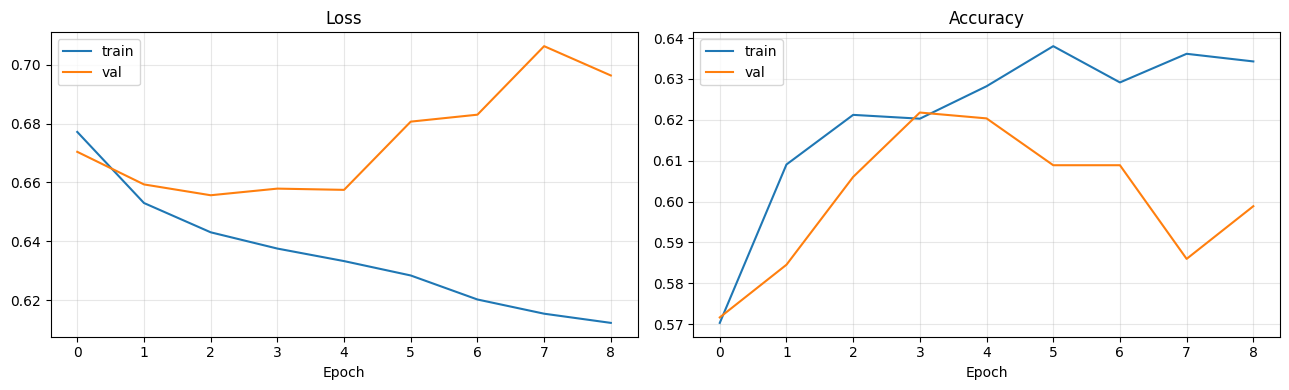

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(history['train_loss'], label='train'); ax.plot(history['val_loss'], label='val')
ax.set_title('Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(history['train_acc'], label='train'); ax.plot(history['val_acc'], label='val')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(DATA_DIR / 'lstm_training.png', dpi=120)
plt.show()


## 6.7 Evaluacion en val y test

In [8]:
@torch.no_grad()
def predict(dl):
    model.eval()
    probs = []; ys = []
    for X, y in dl:
        X = X.to(DEVICE)
        p = torch.softmax(model(X), dim=1)[:, 1].cpu().numpy()
        probs.append(p); ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

p_va, y_va_arr = predict(dl_va)
p_te, y_te_arr = predict(dl_te)

def eval_set(probs, y, name):
    preds = (probs > 0.5).astype(int)
    print(f'\n[{name}] n={len(y)}')
    print(f'  Accuracy: {accuracy_score(y, preds):.4f}')
    print(f'  F1:       {f1_score(y, preds):.4f}')
    print(f'  AUC-ROC:  {roc_auc_score(y, probs):.4f}')
    print(f'  Brier:    {brier_score_loss(y, probs):.4f}')
    print(f'  Class balance true: {y.mean():.3f}  predicted: {preds.mean():.3f}')

eval_set(p_va, y_va_arr, 'VAL')
eval_set(p_te, y_te_arr, 'TEST')



[VAL] n=698
  Accuracy: 0.6060
  F1:       0.6186
  AUC-ROC:  0.6601
  Brier:    0.2319
  Class balance true: 0.474  predicted: 0.559

[TEST] n=1034
  Accuracy: 0.6054
  F1:       0.6396
  AUC-ROC:  0.6609
  Brier:    0.2342
  Class balance true: 0.488  predicted: 0.606


## 6.8 Predicciones full sample (para fases siguientes)
Generamos probabilidades p(sube) para TODAS las fechas usables (train/val/test) y las guardamos junto con el panel original.

In [9]:
# Concatenar predicciones en orden temporal
all_probs = np.concatenate([predict(dl_tr)[0], p_va, p_te])
all_idx   = np.concatenate([idx_tr, idx_va, idx_te])

preds_df = pd.DataFrame({'lstm_prob_up': all_probs}, index=pd.DatetimeIndex(all_idx))
preds_df['split'] = 'train'
preds_df.loc[idx_va, 'split'] = 'val'
preds_df.loc[idx_te, 'split'] = 'test'

# Mergear con features
out = df.join(preds_df, how='left')
out['lstm_prob_up'] = out['lstm_prob_up'].fillna(0.5)  # primeras 60 obs sin prediccion
out.to_parquet(DATA_DIR / 'features_with_lstm.parquet')
print(f'Guardado: data/features_with_lstm.parquet')
print(out[['spread_z','lstm_prob_up','target_direction','split']].tail())


Guardado: data/features_with_lstm.parquet
            spread_z  lstm_prob_up  target_direction split
Date                                                      
2026-05-04 -0.801474      0.597336                 0  test
2026-05-05  0.081579      0.602636                 0  test
2026-05-06  0.059200      0.580296                 0  test
2026-05-07 -1.214183      0.604688                 1  test
2026-05-08 -0.747609      0.661610                 1  test


## Conclusion Fase 6
- LSTM entrenado con early stopping; mejor val loss seleccionado.
- Anti-leakage verificado: standardizer solo en train, sin shuffle.
- Predicciones en val/test y panel enriquecido `features_with_lstm.parquet` para fases 7-8.

**Importante**: en finanzas, accuracy de 52-55% ya es muy bueno (la base es ~50%). Lo que importa no es batir 50% por mucho, sino que la **señal sea consistente y aproveche tail events** que el RL pueda monetizar.
